# [Introduction to Machine Learning Course](https://albarqouni.github.io/courses/iml2022/)
**Instructor:** Prof. [Shadi Albarqouni](https://albarqouni.github.io/), University of Bonn 

## **Lab. 01:** [Logistic Regression](https://albarqouni.github.io/courses/iml2022/Lect03.pdf)

*The lab is borrowed from Andrew Ng's ML course. It was converted from Matlab to Python by Eng. Thaer Sahmoud, and fine-tuned and checked by Shadi Albarqouni.*

### **Goal:** This exercise will teach you how to implement logistic regression and apply it to two datasets. It is highly recommended that you watch the video lectures before starting the programming exercise.


### **Exercise:** In this assignment, you will build a logistic regression model to predict whether a student will be admitted to a university. You run a university department and need to determine the chances of each applicant of getting into the college based on their results on two exams. As a training set for logistic regression, you have historical data from previous applicants. There are two exams that an applicant took, as well as the admissions decision for each training example.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.optimize as opt

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

# Load and read the dataset 
dataset_1 = pd.read_csv(r"C:\Users\sajaa\OneDrive\Desktop\college\second year\2.1\تعلم الآلة\Assignments\lab01\ex2data1.csv") # create ML folder inside MyDrive and copy ex2 inside. 
dataset_1.columns=['Exam 1 score','Exam 2 score','y']
dataset_1.head()

,Exam 1 score,Exam 2 score,y
0,30.286711,43.894998,0
1,35.847409,72.902198,0
2,60.182599,86.308552,1
3,79.032736,75.344376,1
4,45.083277,56.316372,0


## Visualizing the data
A good practice before implementing any learning algorithm is to visualize the data if possible. A previous cell loads the data and stores it in three columns; Exam 1 score, Exam 2 score, and admission as 1 for admitted and 0 for not admitted. Display the data on a 2-dimensional plot by calling the function ```plotData```

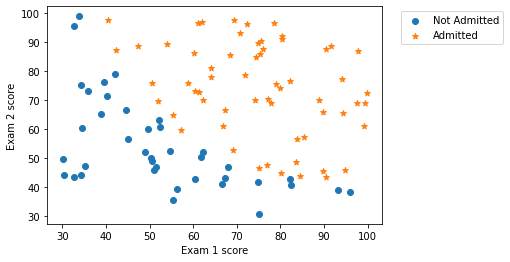

In [3]:
def plotData(dataset):
    dataset['Admission decision']= dataset['y'].replace([1,0],['Admitted','Not Admitted'])
    mask = dataset['y'] == 1
    not_adm = plt.scatter(dataset[~mask]['Exam 1 score'].values, dataset[~mask]['Exam 2 score'].values)
    adm = plt.scatter(dataset[mask]['Exam 1 score'].values, dataset[mask]['Exam 2 score'].values, marker='*')
    
    plt.xlabel('Exam 1 score')
    plt.ylabel('Exam 2 score')
    plt.legend(['Not Admitted', 'Admitted'], bbox_to_anchor=(1.04, 1), loc="upper left")       
    

plotData(dataset_1)

## Implementation


*   **Sigmoid function:** As you might have learned during the lecture, one of the first steps to build your cost function is writing the activation sigmoid function $\sigma(\cdot)$ ```sigmoid``` which basically takes the logit an input $a_n$, and outputs the preciction $\mu_n$ 

In [4]:
# sigmoid function sigmoid(a)
  # - a: logit 
  # - mu: prediction 
def sigmoid(a):
    z = np.exp(-a)
    mu = 1 / (1 + z)
    return mu 

sigmoid(0.25)

0.5621765008857981

In [5]:
from scipy.special import expit

x = 0.25
sig = expit(x)
sig

0.5621765008857981

*   **Cost function:** Now you are supposed to write the Negative Log Liklihood (NLL) as your cost function ```costFunction``` which basically takes the design matrix $X$ along with the taregt labels $Y$ and output the cost $J = NLL(\theta)$ and the gradient $g = \nabla_{\theta}NLL(\theta)$ for a given parameter $\theta$. You can use the following formulas in your code: $NLL(\theta) = - \frac{1}{N} \sum_{n=1}^{N} y_n\log{\mu_n} + (1-y_n)\log{(1-\mu_n)}$ and $\nabla_{\theta}NLL(\theta) = \frac{1}{N} \sum_{n=1}^{N} (\mu_n - y_n)x_n$



In [6]:
# cost function
  # - X: input design matrix of size N samples x D features
  # - Y: taregt labels of size N samples x C labels
  # - theta: parameters of size D x 1 
  # - J: the value of the cost function computed at parameter theta
  # - g: the gradient of the cost function computed at parameter theta
  # - H: the Hessian matrix (optional)
def costFunction(theta, x, y):
    n = len(x) #99,  data points
    d = y.shape[1]
    if theta.shape != (d, 1): #adding new dimintion to theta that has 1 dim 
        theta = theta.reshape(-1,1)
    a = x @ theta # decision boundary
    sigm = sigmoid(a) # Mu
    
    J = - (1/n) * np.sum( (y.T @ np.log(sigm)) + ((1-y).T @ np.log(1-sigm)) ) # NLL
    
    g = (1/n) * ((sigm - y).T @ x) # shape of g = (1,3) --> (sigm (99,1) - y(99,1)).T (1,99) @ x(99,3)
    
    sigm = sigm.reshape(-1)
    H = (1/n) * (x.T @ np.diag(sigm*(1-sigm)))@ x
    return J, g.T, H

*   **Decision Boundary:** Given a value of $theta$, write the function ```plotDecisionBoundary``` to plot the data together with the decision boundary. 

In [7]:
def plotDecisionBoundary(X,y,theta):
    plotData(dataset_1)
    y_values = - (theta[0] + theta[1]*dataset_1['Exam 1 score']) / (theta[2])
    plt.plot(dataset_1['Exam 1 score'], y_values )
    plt.show()


*   **Sanity Check:** Let's test the ```costFunction``` and ```plotDecisionBoundary``` function with a few thetas $\theta$, for example, when $\theta = [0,0,0] $ and $\theta = [-24, 0.2, 0.2]$. To do so, read the data and store them in X and Y before you initialize $\theta$ and pass it to the ```costFunction``` to get the cost and the gradient. Plot the decision boundary

In [19]:
m = dataset_1.shape[0]
X = np.hstack((np.ones((m,1)),dataset_1[['Exam 1 score', 'Exam 2 score']].values))
y = np.array(dataset_1.y.values).reshape(-1,1)


Cost at initial theta (zeros): 0.6931471805599452
Expected cost (approx): 0.693
Gradient at initial theta (zeros):
[[ -0.10606061]
 [-12.30538878]
 [-11.77067239]]
Expected gradients (approx):
 -0.1000
 -12.0092
 -11.2628


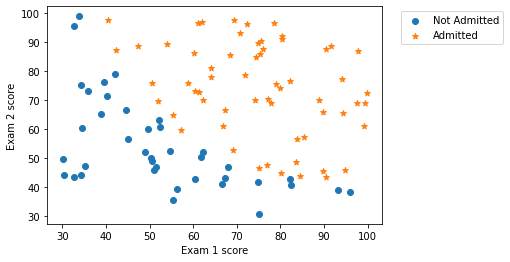

In [9]:
# theta = [0,0,0]
initial_theta = np.zeros(shape=(X.shape[1]))
cost, grad, H = costFunction(initial_theta, X, y)
print('Cost at initial theta (zeros):', cost)
print('Expected cost (approx): 0.693')
print('Gradient at initial theta (zeros):')
print(grad)
print('Expected gradients (approx):\n -0.1000\n -12.0092\n -11.2628')
plotDecisionBoundary(X,y,initial_theta)

Cost at test theta: 0.21844573120599173
Expected cost (approx): 0.218
Gradient at test theta:
[[0.04144856]
 [2.52679301]
 [2.52623742]]
Expected gradients (approx):
 0.043
 2.566
 2.647


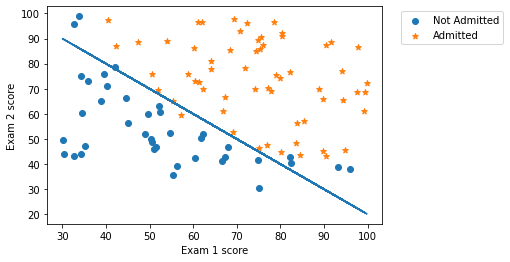

In [10]:
# theta = [-24,0.2,0.2]
test_theta = np.array([-24, 0.2, 0.2])
[cost, grad, H] = costFunction(test_theta, X, y)

print('Cost at test theta:', cost)
print('Expected cost (approx): 0.218')
print('Gradient at test theta:')
print(grad)
print('Expected gradients (approx):\n 0.043\n 2.566\n 2.647')
plotDecisionBoundary(X,y,test_theta)

*   **Optimization:** We learned during the class how to minimize the cost fucntion using either first or second order methods. Implment the optimizer ```optimizeCostFunction``` using the first-order method: $\theta_{t+1} = \theta_t - \eta_t g_t = \theta_t - \eta_t\frac{1}{N}\sum_{n=1}^{N}(\mu_n - y_n)x_n$

In [11]:
# Use the automatic solvers opt.optimize 

def optimize_theta(initial_theta, X, y):
    opt_results = opt.minimize(costFunction, initial_theta, args=(X, y), method='TNC', jac=True, options={'maxiter':400})
    return opt_results['x'], opt_results['fun']

In [14]:
# Write your own optimizer using first- or second-order derivates 

def optimizeCostFunction(init_theta, X, Y, learning_rate, maxiter,order):
    
    theta = init_theta.reshape(-1,1)
    cost, grad, H = costFunction(init_theta, X, y)
    i = 1
    while (i <= maxiter):
        print(f"Iteration # {i} Cost: {round(cost,2)}")
        if order == 2:
            theta = theta - (learning_rate *(np.linalg.inv(H)@ grad))
        else:
            theta = theta - (learning_rate * grad)
        i += 1
        cost, grad, H = costFunction(theta, X, y)
    print(theta.shape)
    return theta, cost


Iteration # 1 Cost: 0.9
Iteration # 2 Cost: 0.9
Iteration # 3 Cost: 0.89
Iteration # 4 Cost: 0.89
Iteration # 5 Cost: 0.88
Iteration # 6 Cost: 0.87
Iteration # 7 Cost: 0.87
Iteration # 8 Cost: 0.86
Iteration # 9 Cost: 0.86
Iteration # 10 Cost: 0.85
Iteration # 11 Cost: 0.85
Iteration # 12 Cost: 0.84
Iteration # 13 Cost: 0.83
Iteration # 14 Cost: 0.83
Iteration # 15 Cost: 0.82
Iteration # 16 Cost: 0.82
Iteration # 17 Cost: 0.81
Iteration # 18 Cost: 0.81
Iteration # 19 Cost: 0.8
Iteration # 20 Cost: 0.8
Iteration # 21 Cost: 0.79
Iteration # 22 Cost: 0.79
Iteration # 23 Cost: 0.79
Iteration # 24 Cost: 0.78
Iteration # 25 Cost: 0.78
Iteration # 26 Cost: 0.77
Iteration # 27 Cost: 0.77
Iteration # 28 Cost: 0.76
Iteration # 29 Cost: 0.76
Iteration # 30 Cost: 0.76
Iteration # 31 Cost: 0.75
Iteration # 32 Cost: 0.75
Iteration # 33 Cost: 0.74
Iteration # 34 Cost: 0.74
Iteration # 35 Cost: 0.74
Iteration # 36 Cost: 0.73
Iteration # 37 Cost: 0.73
Iteration # 38 Cost: 0.72
Iteration # 39 Cost: 0.72

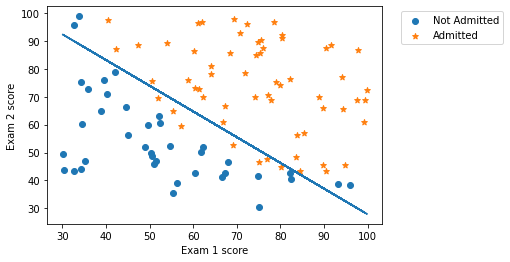

Cost at theta found by fminunc: 0.20455746161380958
Expected cost (approx): 0.203
theta:
 [[-24.88591653]
 [  0.20348179]
 [  0.20003686]]
Expected theta (approx):
 -25.161
 0.206
 0.201


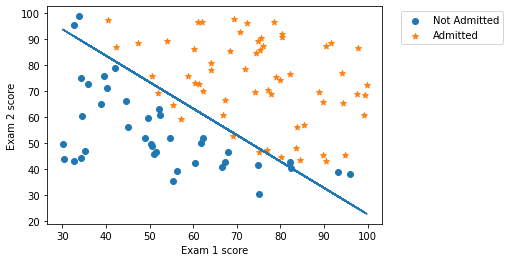

In [22]:
random_theta = 0.02*np.random.randn(X.shape[1])
opt_theta_1, cost_1 = optimizeCostFunction(random_theta, X, y, 0.005, 400,2)
print('Cost at theta found by fminunc:', cost_1)
print('Expected cost (approx): 0.203')
print('theta:\n', opt_theta_1.reshape(-1,1))
print('Expected theta (approx):')
print(' -25.161\n 0.206\n 0.201')
plotDecisionBoundary(X,y,opt_theta_1)

opt_theta_2, cost_2 = optimize_theta(random_theta, X, y)
print('Cost at theta found by fminunc:', cost_2)
print('Expected cost (approx): 0.203')
print('theta:\n', opt_theta_2.reshape(-1,1))
print('Expected theta (approx):')
print(' -25.161\n 0.206\n 0.201')
plotDecisionBoundary(X,y,opt_theta_2)

## Inference and Evaluation

**Inference:** Given a new query data point $x_q$, for example, a student with Exam 1 score of 45 and Exam 2 score of 85, what is the chance that of the student to be admitted to the school? Write a function ```predict``` which takes the $x_q$ and $\theta_{opt}$ as input, and return the prediction $\mu_q = \sigma(a_q)$. 

In [83]:
# given the optimal theta 
# - y_pred: the predicted label 
# - y_prop: the probability of p(y = 1| x, theta)
def predict(x, opt_theta):
    a = opt_theta.T @ x
    y_prop = sigmoid(a)
    
    from sklearn.linear_model import LogisticRegression
    lr = LogisticRegression(C=100.0, random_state=0, verbose=2)
    x = x.reshape(-1,1).T
    X_input = X
    y_input = y.ravel()
    classifier = lr.fit(X_input, y_input)
    y_pred = classifier.predict(x)
    total_y_predict = classifier.predict(X_input)

    return y_pred, y_prop, total_y_predict

pred, prob, total_pre = predict(np.array([1, 45, 85]),opt_theta_1)
print('For a student with scores 45 and 85, we predict an admission probability of', prob)
print('Expected value: 0.775 +/- 0.002')


For a student with scores 45 and 85, we predict an admission probability of [0.66074371]
Expected value: 0.775 +/- 0.002


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


**Evaluation:** Write the function ```evaluateModel``` which takes the input design matrix $X$, target $y$, and the optimal weight parameters $\theta_{opt}$, and return the accuracy of the model. 


In [87]:
def evaluateModel(X,y,opt_theta):
    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y, total_pre)
    print('Train accuracy:', round(acc,4)*100,'%')

X = np.hstack((np.ones((m,1)),dataset_1[['Exam 1 score', 'Exam 2 score']].values))
y = dataset_1.y
evaluateModel(X,y, opt_theta_1)

Train accuracy: 88.89 %
